_______________ITERATION :0_______________
Center : [2, 10] --- Points : [[2, 10], [2, 5], [8, 4]]
Center : [5, 8] --- Points : [[5, 8], [7, 5], [6, 4]]
Center : [1, 2] --- Points : [[1, 2], [4, 9]]
[0, 5, 9] --- Cluster : 1
[5, 6, 4] --- Cluster : 3
[12, 7, 9] --- Cluster : 2
[5, 0, 10] --- Cluster : 2
[10, 5, 9] --- Cluster : 2
[10, 5, 7] --- Cluster : 2
[9, 10, 0] --- Cluster : 3
[3, 2, 10] --- Cluster : 2
---------------NEW CLUSTERS---------------
CLUSTER 1 : [(2, 10)]
CLUSTER 2 : [(8, 4), (5, 8), (7, 5), (6, 4), (4, 9)]
CLUSTER 3 : [(2, 5), (1, 2)]
---------------NEW CENTERS---------------
Cluster 1 center : [2.0, 10.0]
Cluster 2 center : [6.0, 6.0]
Cluster 3 center : [1.5, 3.5]
_______________END OF ITERATION :0_______________
_______________ITERATION :1_______________
Center : [2.0, 10.0] --- Points : [[2, 10], [2, 5], [8, 4]]
Center : [6.0, 6.0] --- Points : [[5, 8], [7, 5], [6, 4]]
Center : [1.5, 3.5] --- Points : [[1, 2], [4, 9]]
[0.0, 8.0, 7.0] --- Cluster : 1
[5.0, 5.0, 2.0

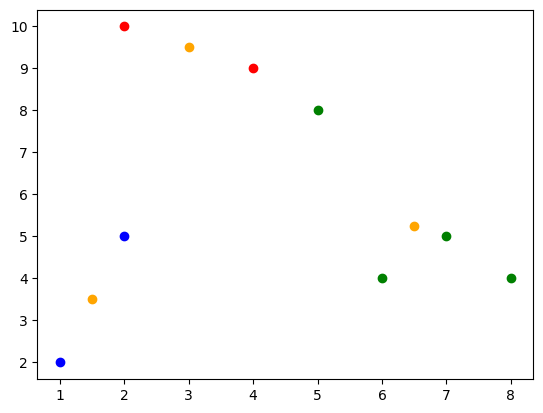

In [3]:
'''
Title : KNN
Author : raghav | GitHub : @raghavtwenty
Date Created : May 24, 2023 | Last Updated : May 26, 2023
Language : Python | Version : 3.11.3
'''


# Imports
import numpy as np
import matplotlib.pyplot as mpl


# Data points
data = [(2, 10), (2, 5), (8, 4), (5, 8), (7, 5), (6, 4), (1, 2), (4, 9)]
df = np.array(data)

# Center point calulation
def cen(arr):

    x_cen , y_cen = 0,0
    arr_len = len(arr)
    
    for ar in arr:
        x_cen += ar[0]
        y_cen += ar[1]

    x_cen /= arr_len
    y_cen /= arr_len

    return [x_cen, y_cen]


# Distance calulation function - MANHATTAN
def dis(a, b):
    a_dis = abs(a[0]-b[0])
    b_dis = abs(a[1]-b[1])
    return a_dis+b_dis


# KNN 
def knn(initial_centers,ite):

    print("_"*15+"ITERATION :"+str(ite)+"_"*15)

    global new_clus1, new_clus2, new_clus3

    # Center and corresponding points
    for bl in range(len(batch_lis)):
        print(f"Center : {initial_centers[bl]} --- Points : {batch_lis[bl]}")


    temp_new_clus = []
    for jj in data:
        temp_new_clus.append([
                            dis(initial_centers[0], jj),
                            dis(initial_centers[1], jj),
                            dis(initial_centers[2], jj)])


    new_clus1 = []
    new_clus2 = []
    new_clus3 = []
    count = 0
    for i in temp_new_clus:

        temp_min = min(i)
        temp_clus_loc = i.index(temp_min)+1
        clus_element = data[count]

        # Append into the corresponding clusters
        if temp_clus_loc == 1:
            new_clus1.append(clus_element)
        elif temp_clus_loc == 2:
            new_clus2.append(clus_element)
        else:
            new_clus3.append(clus_element)

        print(f"{i} --- Cluster : {temp_clus_loc}")
        count = count + 1
        

    print("-"*15+"NEW CLUSTERS"+"-"*15)
    print(f"CLUSTER 1 : {new_clus1}")
    print(f"CLUSTER 2 : {new_clus2}")
    print(f"CLUSTER 3 : {new_clus3}")


    print("-"*15+"NEW CENTERS"+"-"*15)
    nc1,nc2,nc3 = cen(new_clus1),cen(new_clus2),cen(new_clus3)
    print(f"Cluster 1 center : {nc1}")
    print(f"Cluster 2 center : {nc2}")
    print(f"Cluster 3 center : {nc3}")

    print("_"*15+"END OF ITERATION :"+str(ite)+"_"*15)

    return [nc1,nc2,nc3]



# ----- MAIN
# print(df)
# Number of cluster input
# clus = int(input("Enter the Number of Clusters : "))
clus = 3
# itera = int(input("Enter the Number of iteration : "))
itera = 2

# Batch split by group
batched_data = np.array_split(df, clus)

# Print batched data
batch_lis = []
for _ in batched_data:
    # Add each element to list
    batch_lis.append(_.tolist())


# Initial centers 
initial_centers = []
for i in batch_lis:
    initial_centers.append(i[0])


# Call KNN as per the number of iteration given
for i in range(itera):
    # Call the KNN function
    initial_centers = knn(initial_centers,i)


# plot
x = [i[0] for i in new_clus1]
y = [i[1] for i in new_clus1]
mpl.scatter(x,y,color='r')

x = [i[0] for i in new_clus2]
y = [i[1] for i in new_clus2]
mpl.scatter(x,y,color='g')

x = [i[0] for i in new_clus3]
y = [i[1] for i in new_clus3]
mpl.scatter(x,y,color='b')

# plotting the centers
for i in range(clus):
    mpl.scatter(initial_centers[i][0], initial_centers[i][1], color = 'orange')
mpl.show()


Yellow marks - Centers <br>
Cluster 1 - Red Color <br>
Cluster 2 - Green Color <br>
Cluster 3 - Blue Color <br>